In [1]:
import sys
from os.path import dirname, join as pjoin
from os import listdir
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
plt.rcParams['svg.fonttype'] = 'none'
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
def logistic_prepare_predictors(a,R,n_back,mdl_type='RU'):
    num_trials = len(a)
    
    # Get history matrices
    a_hist, R_hist,_ = prepare_hist_matrix(a,R,n_back)

    # create and align component arrays
    past_rc = np.multiply(a_hist,R_hist)
    past_uc = np.multiply(a_hist,R_hist==0)
    past_c = a_hist
    
    # identifty choice trials
    choice_trials = (a==1)|(a==2)
    left_trials = (a==1)+0
    left_trials[a==2]=-1
    left_choice_trials = left_trials[choice_trials]

    # create output arrays: predictors and targets
    glm_target = left_choice_trials
    if mdl_type=='RU':
        glm_mat = np.concatenate((past_rc[choice_trials,:], \
                                  past_uc[choice_trials,:]),axis=1)
    elif mdl_type=='RC':
        glm_mat = np.concatenate((past_rc[choice_trials,:], \
                                  past_c[choice_trials,:]),axis=1)    
    return glm_mat, glm_target

def prepare_hist_matrix(a,R,n_back):
    # Prepare history matrix
    num_trials = len(a)
    uR = np.zeros(num_trials)
    uR[(R==0) & (a<3)] = 1
    
    # Now pads with zeros
    a_hist = np.zeros((num_trials,n_back))
    R_hist = np.zeros((num_trials,n_back))
    uR_hist = np.zeros((num_trials,n_back))

    a_cleaned = a.copy()+0.
    a_cleaned[a>2] = 0
    a_cleaned[a==2] = -1

    # fill history matrices with n_back information
    for nn in range(n_back):
        a_hist[(1+nn):,nn] = a_cleaned[0:num_trials-nn-1]
        R_hist[(1+nn):,nn] = R[0:num_trials-nn-1]       
        uR_hist[(1+nn):,nn] = uR[0:num_trials-nn-1]  
    
    return np.fliplr(a_hist), np.fliplr(R_hist), np.fliplr(uR_hist)

EZ707 240828 Foraging20_ra
EZ707
ra
EZ707 240829 Foraging20_ra
EZ707
ra
EZ707 240901 Foraging20_ra
EZ707
ra
EZ707 240904 Foraging20_ra
EZ707
ra
EZ715 241106 Foraging20_ra
EZ715
ra
EZ715 241108 Foraging20_ra
EZ715
ra
EZ717 241025 Foraging20_ra
EZ717
ra
EZ717 241026 Foraging20_ra
EZ717
ra
EZ717 241031 Foraging20_ra
EZ717
ra
EZ718 250204 Foraging20_ra
EZ718
ra
EZ718 250206 Foraging20_ra
EZ718
ra
EZ720 250102 Foraging20_ra
EZ720
ra
EZ720 250106 Foraging20_ra
EZ720
ra
EZ722 250415 Foraging20_ra
EZ722
ra
EZ722 250418 Foraging20_ra
EZ722
ra
EZ722 250421 Foraging20_ra
EZ722
ra
EZ729 250722 Foraging20_ra
EZ729
ra
EZ729 250723 Foraging20_ra
EZ729
ra
EZ729 250729 Foraging20_ra
EZ729
ra


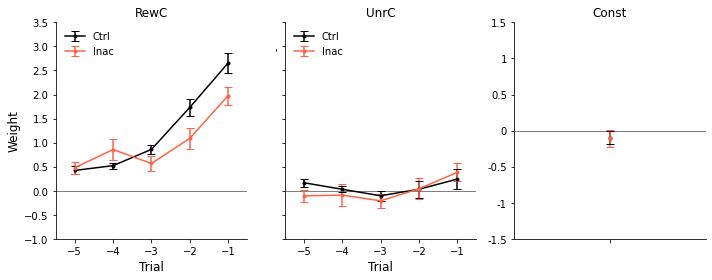

In [5]:
def prepare_opto_predictor_df(a,R,Opto):
    num_trials = len(a)
    n_back = 5
    
    # Get history matrices
    a_hist, R_hist,_ = prepare_hist_matrix(a,R,n_back)

    # create and align component arrays
    past_rc = np.multiply(a_hist,R_hist)
    past_uc = np.multiply(a_hist,R_hist==0)
    past_c = a_hist
    past_R = R_hist
    
    # Codify the dependent variable: choice
    dv = (a==1).astype(int)
    dv = dv.reshape([len(dv),1])
    # codify constant
    const = np.ones(len(a)).reshape([len(a),1])
    
    opto_on = np.where(Opto)[0]
    choice_trials = (a==1)|(a==2)
    opto_choice_trials = ((a==1) | (a==2)) & Opto
    ctrl_choice_trials = ((a==1) | (a==2)) & (Opto==0)
    opto_inds = np.where(opto_choice_trials)[0]
    
    # Legacy variable naming, 3 trials post opto no longer used here
    opto_shift_1 = opto_on+1; opto_shift_1 = opto_shift_1[opto_shift_1<len(a)]
    post3_opto = np.ones(len(Opto)).astype(int)
    post3_opto[opto_on] = 0
    post3_opto[a>2] = 0
    ctrl_inds = np.where(post3_opto)[0]
    
    post_opto_choice_trials = np.zeros(len(Opto)).astype(int) 
    post_opto_inds = opto_shift_1[choice_trials[opto_shift_1]==1]
    post_opto_choice_trials[post_opto_inds] = 1
    
    opto_choice_trials = opto_choice_trials.reshape([len(opto_choice_trials),1])
    post_opto_choice_trials = post_opto_choice_trials.reshape([len(post_opto_choice_trials),1])
    trials_to_use = np.zeros(len(a))
    trials_to_use[opto_inds]=1
    trials_to_use[ctrl_inds]=1
    trials_to_use = trials_to_use.astype(bool)
    
    temp_df = pd.DataFrame(np.hstack([dv[trials_to_use], 
                                      opto_choice_trials[trials_to_use],
                                      post_opto_choice_trials[trials_to_use],
                                      const[trials_to_use],
                                      past_R[trials_to_use,:],
                                      past_rc[trials_to_use,:],
                                      past_uc[trials_to_use,:],
                                      past_c[trials_to_use,:]]),
                  columns=['DV','opto','post_opto','const',
                           'Rp5','Rp4','Rp3','Rp2','Rp1',
                           'RCp5','RCp4','RCp3','RCp2','RCp1',
                           'UCp5','UCp4','UCp3','UCp2','UCp1',
                           'Cp5','Cp4','Cp3','Cp2','Cp1'])

    return temp_df  

def prepare_opto_glm_5(predictor_df, mdl_type):
    n_back = 5
    # Prepare matrices
    opto_params = predictor_df[['opto']].to_numpy()
    glm_target = predictor_df['DV'].values
    
    if mdl_type == 'RU':
        history_params = predictor_df[['RCp5','RCp4','RCp3','RCp2','RCp1',
                                       'UCp5','UCp4','UCp3','UCp2','UCp1']].to_numpy()
        glm_mat = np.concatenate((history_params*np.tile(opto_params==0,[1,2*n_back]),
                                  history_params*np.tile(opto_params==1,[1,2*n_back]),
                                  opto_params
                                 ),axis=1)
    elif mdl_type == 'RC':
        history_params = predictor_df[['RCp5','RCp4','RCp3','RCp2','RCp1',
                                       'Cp5','Cp4','Cp3','Cp2','Cp1']].to_numpy()
        glm_mat = np.concatenate((history_params*np.tile(opto_params==0,[1,2*n_back]),
                                  history_params*np.tile(opto_params==1,[1,2*n_back]),
                                  opto_params
                                 ),axis=1)        
    return glm_mat, glm_target, opto_params, opto_params

def modelfit_subsample_pd(row, reg_type):
    rng = np.random.default_rng(20250323)
    n_back = 5
    mdl_type = 'RU'
    
    row['mdl_penalty'] = reg_type
    subsample_iter = 1000
    sample_size = 0.9
    
    inac,a,R = row[['Inac Type','a','R']]
    if inac=='ra':
        Opto = row['Opto']
    else:
        print('Error. This is not an ra inactivation.')  
    n_choice = sum((a==1)|(a==2))
    choice_trials = (a==1)|(a==2)
    
    predictor_df = prepare_opto_predictor_df(a,R,Opto)
    glm_mat, glm_target, opto_param,_  = prepare_opto_glm_5(predictor_df, mdl_type)
    
    # Subsampling
    n_iterations = subsample_iter
    opto_inds = np.where(opto_param)[0]
    ctrl_inds = np.where(opto_param==0)[0]
    n_opto = len(opto_inds)
    n_per_iteration = np.floor(n_opto*sample_size).astype(int)
    n_per_test = n_opto-n_per_iteration

    for nn in range(n_iterations):
        perm_ctrl = rng.permutation(ctrl_inds)
        perm_opto = rng.permutation(opto_inds)
        ctrl_train = perm_ctrl[:n_per_iteration]
        ctrl_test = perm_ctrl[n_per_iteration:n_per_iteration+n_per_test]
        opto_train = perm_opto[:n_per_iteration]
        opto_test = perm_opto[n_per_iteration:n_per_iteration+n_per_test]

        train_inds = np.concatenate([opto_train, ctrl_train])
        train_inds.sort()
        test_inds = np.concatenate([opto_test, ctrl_test])
        test_inds.sort()
        n_test = len(test_inds)

        # Estimate regression
        if reg_type=='none':
            log_reg = LogisticRegression(solver='newton-cg', penalty='none', n_jobs=-1, random_state=0)
        if reg_type=='l1':
            log_reg = LogisticRegressionCV(solver='saga', cv=5, penalty=reg_type, n_jobs=-1, random_state=0, refit=True)
        if reg_type=='l2':
            log_reg = LogisticRegressionCV(solver='saga', cv=5, penalty=reg_type, n_jobs=-1, random_state=0, refit=True)
        if reg_type=='elasticnet':
            log_reg = LogisticRegressionCV(
            solver='saga', cv=5, penalty='elasticnet', l1_ratios=[.1, .5, .7, .9],
            n_jobs=-1, random_state=0, refit=True)
        
        fit_mdl = log_reg.fit(glm_mat[train_inds,:],glm_target[train_inds])    

        coef = fit_mdl.coef_[0]
        intercept = fit_mdl.intercept_[0]

        temp_coef = coef.copy()
        temp_coef[-1] = temp_coef[-1]+intercept
        mdl_coef = np.append(temp_coef, intercept)

        if nn==0:
            all_coef_mat = mdl_coef.copy()
        else:
            all_coef_mat = np.vstack((all_coef_mat, mdl_coef))

    row['mean_weights'] = np.nanmean(all_coef_mat,0)
    row['median_weights'] = np.nanmedian(all_coef_mat,0)

    return row

def plot_opto_regression_ru(ax, ax_ind, mean_vec, sem_vec, opto_color):
    n_back = 5
    x_plt = -np.linspace((n_back),1,n_back)
    ax[ax_ind].plot([-11,0], [0,0], c='grey', linewidth=1)
    ax[ax_ind].errorbar(x_plt, mean_vec[r_ru5_ctrl_inds], sem_vec[r_ru5_ctrl_inds],
                     c='k', marker='o', markersize=3, linestyle='-', capsize=4,label='Ctrl')
    ax[ax_ind].errorbar(x_plt, mean_vec[r_ru5_opto_inds], sem_vec[r_ru5_opto_inds],
                     c=opto_color, marker='o', markersize=3, linestyle='-', capsize=4, label='Inac')
    ax[ax_ind].set_xticks(x_plt)
    ax[ax_ind].set_xlim([-5.5,-.5])
    ax[ax_ind].set_yticks([-1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5])
    if ax_ind>0:
        ax[ax_ind].set_yticklabels(['', '', '', '', '', '', '', '', '', '',''])
        
def plot_opto_regression_ru_unr(ax, ax_ind, mean_vec, sem_vec, opto_color):
    n_back = 5
    x_plt = -np.linspace((n_back),1,n_back)
    ax[ax_ind].plot([-11,0], [0,0], c='grey', linewidth=1)
    ax[ax_ind].errorbar(x_plt, mean_vec[u_ru5_ctrl_inds], sem_vec[r_ru5_ctrl_inds],
                     c='k', marker='o', markersize=3, linestyle='-', capsize=4,label='Ctrl')
    ax[ax_ind].errorbar(x_plt, mean_vec[u_ru5_opto_inds], sem_vec[r_ru5_opto_inds],
                     c=opto_color, marker='o', markersize=3, linestyle='-', capsize=4, label='Inac')
    ax[ax_ind].set_xticks(x_plt)
    ax[ax_ind].set_xlim([-5.5,-.5])
    ax[ax_ind].set_yticks([-1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5])
    if ax_ind>0:
        ax[ax_ind].set_yticklabels(['', '', '', '', '', '', '', '',',',''])

def sem(y):
    if len(np.shape(y))==1:
        return np.nanstd(y)/np.sqrt(len(y)-1)
    else:
        n,_ = np.shape(y)
        return np.nanstd(y,0)/np.sqrt(n-1)

def analyze_sessions(server_dir, date_start='220101', to_plot=True):
    pythonlist = listdir(server_dir)
    all_weights = []
    session_info = []
    
    for ss in range(len(pythonlist)):
        if pythonlist[ss][-3:]=='pkl':
            mouse = pythonlist[ss][:5]
            date = pythonlist[ss][6:12]
            if (int(date)>int(date_start)):
                session_type = pythonlist[ss][13:-4]
                print(mouse, date, session_type)
                df1 = pd.read_pickle(pjoin(server_dir, pythonlist[ss]))
                a = df1['a']
                R = df1['R']
                opto = df1['opto']
                opto_notes = df1.loc[0,'OptoNotes']

                if sum(opto)>0:
                    inac_type = 'ra'
                    temp_df = pd.DataFrame({'Mouse': mouse, 'a': [a.values], 'R': [R.values], 
                                          'Opto': [opto.values], 'Inac Type': inac_type})
                    opto_reg_df = temp_df.apply(modelfit_subsample_pd,axis=1, args=['l1'])
                    print(mouse)
                    print(inac_type)
                    # Store weights and session info
                    all_weights.append(opto_reg_df.loc[0,'mean_weights'])
                    session_info.append({
                        'mouse': mouse,
                        'date': date,
                        'session_type': session_type,
                        'opto_notes': opto_notes
                    })

    # Convert to numpy array for analysis
    all_weights_array = np.array(all_weights)
    mean_vec = np.nanmean(all_weights_array,0)
    sem_vec = sem(all_weights_array)

    # Save weights and session info
    weights_data = {
        'weights': all_weights_array,
        'mean_weights': mean_vec,
        'sem_weights': sem_vec,
        'session_info': session_info
    }

    pd.to_pickle(weights_data, pjoin(server_dir, 'opto_summary_pkl_files/PPC_Long_1000iter.pkl'))

    if to_plot:
        # Define indices for plotting
        global r_ru5_ctrl_inds, u_ru5_ctrl_inds, r_ru5_opto_inds, u_ru5_opto_inds
        r_ru5_ctrl_inds = slice(0,5)
        u_ru5_ctrl_inds = slice(5,10)
        r_ru5_opto_inds = slice(10,15)
        u_ru5_opto_inds = slice(15,20)

        # Create summary plot
        f,ax = plt.subplots(1,3, sharey=False, sharex=False, figsize = [10, 4], tight_layout=False)
        
        plot_opto_regression_ru(ax, 0, mean_vec, sem_vec, 'tomato')
        ax[0].set_ylim([-1,3.5])
        ax[0].set_title('RewC',fontsize=12)
        ax[0].set_ylabel('Weight',fontsize=12)
        ax[0].set_xlabel('Trial',fontsize=12)
        ax[0].legend(loc='upper left', frameon=False)
        ax[0].spines['top'].set_visible(False)
        ax[0].spines['right'].set_visible(False)

        plot_opto_regression_ru_unr(ax, 1, mean_vec, sem_vec, 'tomato')
        ax[1].set_title('UnrC',fontsize=12)
        ax[1].set_xlabel('Trial',fontsize=12)
        ax[1].legend(loc='upper left', frameon=False)
        ax[1].spines['top'].set_visible(False)
        ax[1].spines['right'].set_visible(False)

        ax[2].plot([-11,0], [0,0], c='grey', linewidth=1)
        ax[2].errorbar(-5, mean_vec[-1], sem_vec[-1],
                     c='k', marker='o', markersize=3, linestyle='-',capsize=4)
        ax[2].errorbar(-5, mean_vec[-2], sem_vec[-2],
                     c='tomato', marker='o', markersize=3, linestyle='-', capsize=4)
        ax[2].set_title('Const')
        ax[2].set_xticks([-5]); ax[2].set_xticklabels([''])
        ax[2].set_xlim([-6,-4])
        ax[2].set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
        ax[2].set_yticklabels(['-1.5','-1','-0.5','0','0.5','1','1.5'])
        ax[2].spines['top'].set_visible(False)
        ax[2].spines['right'].set_visible(False)

        plt.tight_layout()

if __name__ == "__main__":
    server_dir = "Z:\\People\\Eva\\bpod_processed_data_opto"  # Replace with your data directory
    analyze_sessions(server_dir, date_start='220101', to_plot=True)

